In [1]:
import numpy as np
import matplotlib.pyplot as plt
import squarify
import matplotlib.dates as dates
from datetime import datetime
import polars as pl
%matplotlib inline

In [2]:
# data = pl.scan_csv('/home/chien/Big_Data/product/2019-*.csv')
data = pl.scan_csv(
    "/home/chien/Big_Data/product/2019-Nov.csv",
    dtypes={
        "product_id": pl.Int64,
        "category_id": pl.Int64,
        "user_id": pl.Int64,
        "price": pl.Float32,
        "event_time": pl.Utf8
    }
)
data = data.filter(
    pl.col("user_session").is_not_null() & 
    pl.col("user_id").is_not_null() & 
    pl.col("product_id").is_not_null()
)
data = data.with_columns(
    pl.col(["brand", "category_code"]).fill_null("unknown")
)
data_clean = data.collect()

/tmp/ipykernel_37585/752482552.py:2: DeprecationWarning: the argument `dtypes` for `scan_csv` is deprecated. It was renamed to `schema_overrides` in version 0.20.31.
  data = pl.scan_csv(


In [3]:
data_clean.shape

(67501969, 9)

In [4]:
data_clean.schema

Schema([('event_time', String),
        ('event_type', String),
        ('product_id', Int64),
        ('category_id', Int64),
        ('category_code', String),
        ('brand', String),
        ('price', Float32),
        ('user_id', Int64),
        ('user_session', String)])

In [5]:
data_clean.glimpse

<bound method DataFrame.glimpse of shape: (67_501_969, 9)
┌────────────┬───────────┬───────────┬───────────┬───┬─────────┬───────────┬───────────┬───────────┐
│ event_time ┆ event_typ ┆ product_i ┆ category_ ┆ … ┆ brand   ┆ price     ┆ user_id   ┆ user_sess │
│ ---        ┆ e         ┆ d         ┆ id        ┆   ┆ ---     ┆ ---       ┆ ---       ┆ ion       │
│ str        ┆ ---       ┆ ---       ┆ ---       ┆   ┆ str     ┆ f32       ┆ i64       ┆ ---       │
│            ┆ str       ┆ i64       ┆ i64       ┆   ┆         ┆           ┆           ┆ str       │
╞════════════╪═══════════╪═══════════╪═══════════╪═══╪═════════╪═══════════╪═══════════╪═══════════╡
│ 2019-11-01 ┆ view      ┆ 1003461   ┆ 205301355 ┆ … ┆ xiaomi  ┆ 489.07000 ┆ 520088904 ┆ 4d3b30da- │
│ 00:00:00   ┆           ┆           ┆ 563188265 ┆   ┆         ┆ 7         ┆           ┆ a5e4-49df │
│ UTC        ┆           ┆           ┆ 5         ┆   ┆         ┆           ┆           ┆ -b1a8-ba5 │
│            ┆           ┆       

### Visitors Daily Trend

In [6]:
visitor = data_clean.select(pl.col('user_id').n_unique()).item()
print(f"visitors: {visitor}")

visitors: 3696117


In [7]:
data = data_clean.with_columns(
    pl.col("event_time")
    .str.slice(0, 10) # Cắt lấy 10 ký tự đầu (YYYY-MM-DD)
    .str.to_date("%Y-%m-%d") # Ép kiểu sang Date
    .alias("event_date") # Đặt tên cột mới là event_date
)


In [8]:
visitor_by_date = (
    data.select(["event_date", "user_id"])
    .unique() # Thay cho drop_duplicates()
    .group_by("event_date") # Thay cho groupby()
    .agg(pl.len().alias("count")) # Đếm số lượng
    .sort("event_date") # Thay cho sort_values()
)

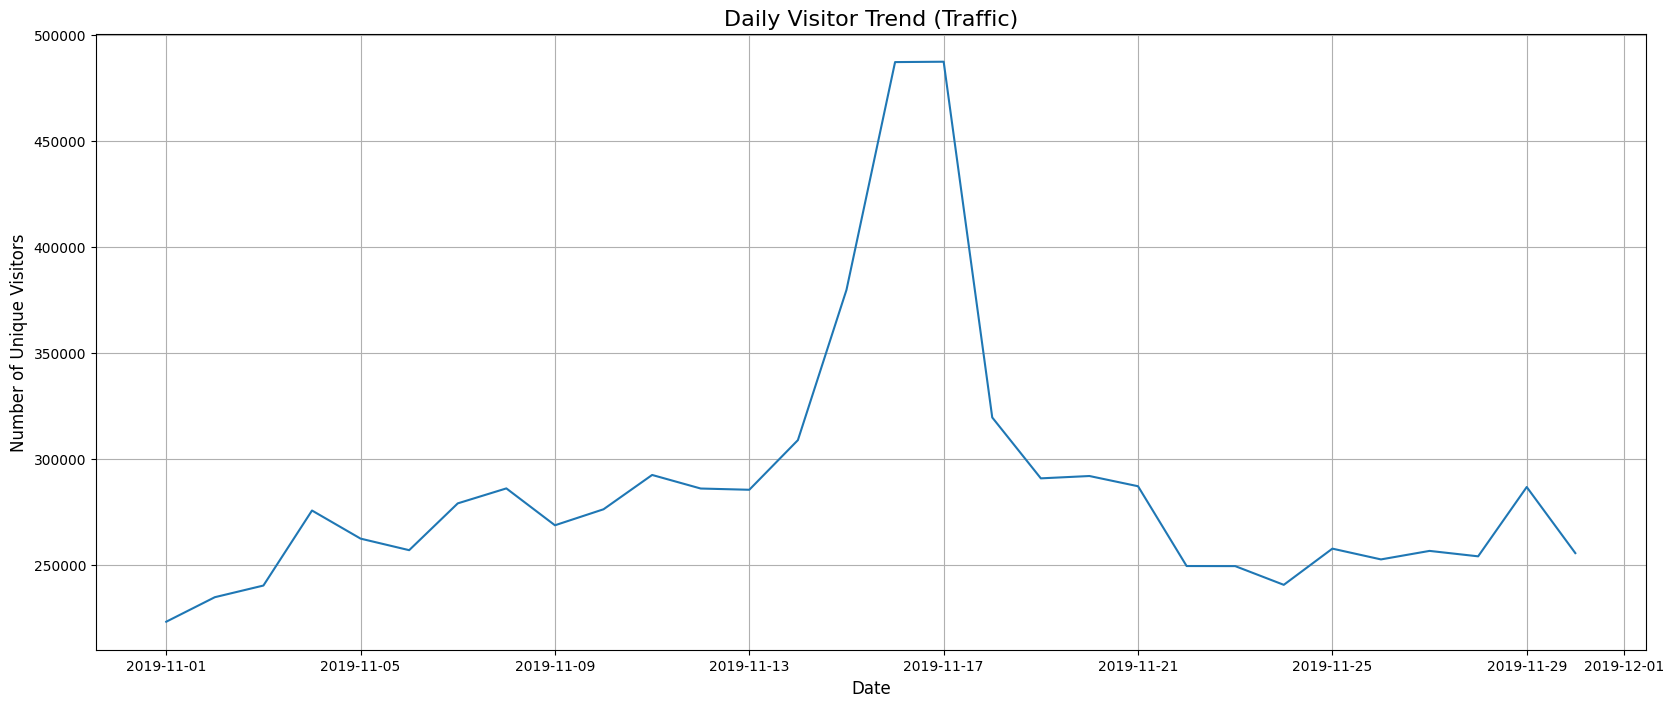

In [9]:
x = visitor_by_date['event_date']
y = visitor_by_date['count']

plt.rcParams['figure.figsize'] = (20,8)

plt.plot(x,y)
plt.title("Daily Visitor Trend (Traffic)", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Number of Unique Visitors", fontsize=12)
plt.grid(True) 
plt.show()

### Price Daily Trend

In [10]:
product_id = 1307067 
data.filter(pl.col("product_id") == product_id) \
    .select(["category_code", "brand"]) \
    .head(1)

category_code,brand
str,str
"""computers.notebook""","""lenovo"""


In [11]:
product_daily_price = (
    data.filter(pl.col("product_id") == product_id)
        .group_by("event_date")
        .agg(pl.col("price").mean())
        .sort("event_date")
)

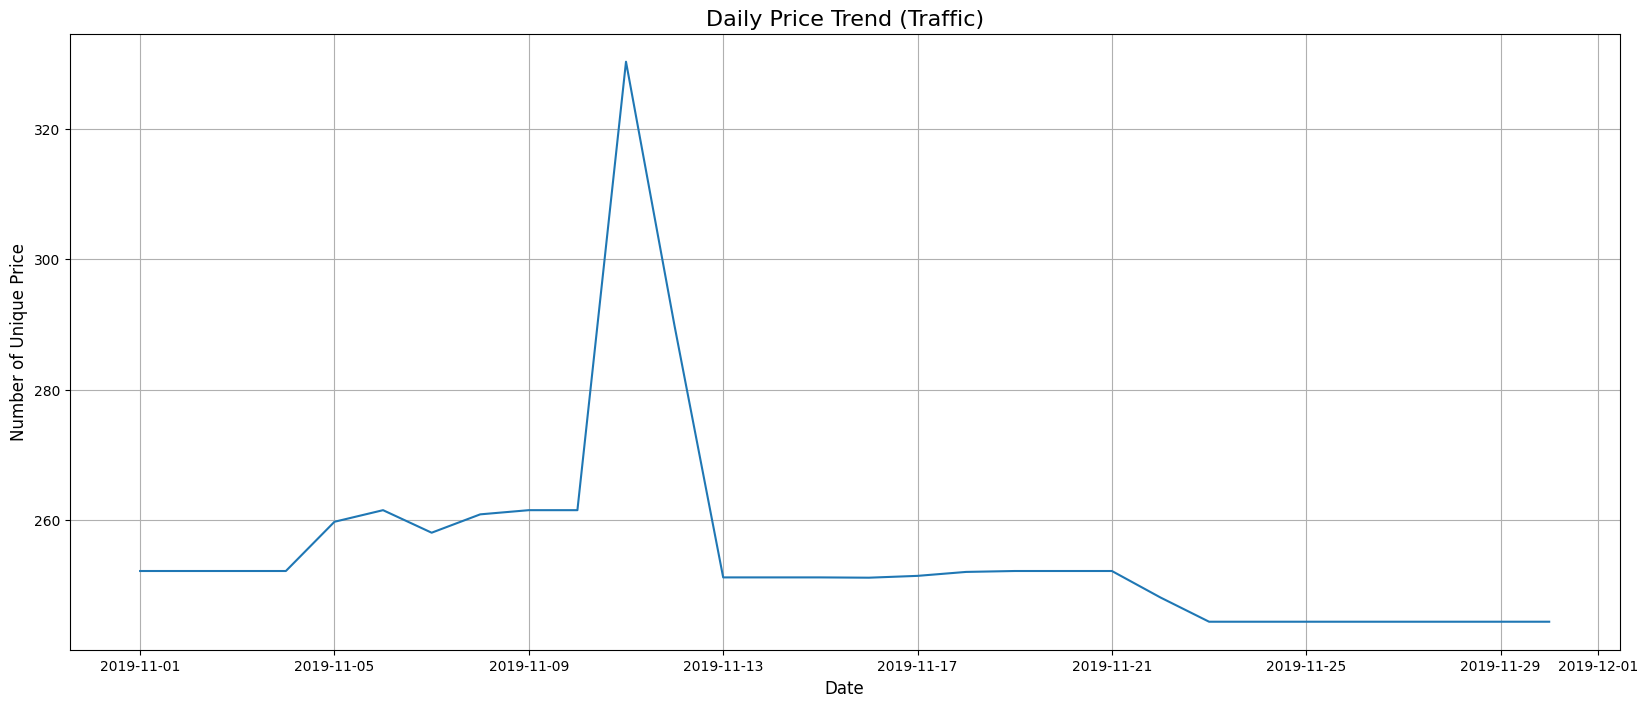

In [12]:
x = product_daily_price["event_date"]
y = product_daily_price["price"]

plt.rcParams['figure.figsize'] = (20,8)

plt.plot(x,y)
plt.title("Daily Price Trend (Traffic)", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Number of Unique Price", fontsize=12)
plt.grid(True) 
plt.show()

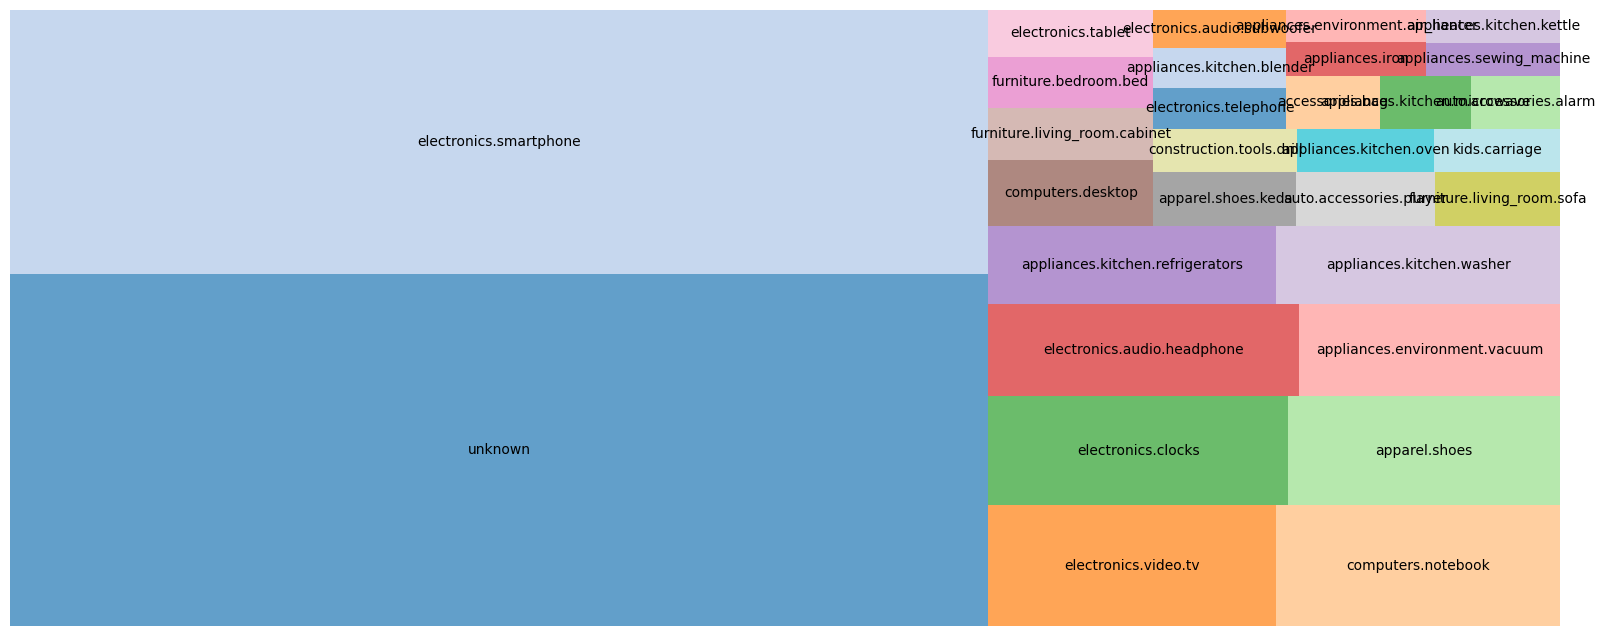

In [13]:
# Đếm top 30 danh mục
top_category = (
    data.get_column("category_code")
    .value_counts()
    .sort("count", descending=True)
    .head(30)
)
sizes = top_category["count"].to_list()
labels = top_category["category_code"].to_list()
colors = plt.cm.tab20.colors

squarify.plot(
    sizes=sizes,
    label=labels,
    color=colors,
    alpha=0.7
)

plt.axis("off")
plt.show()

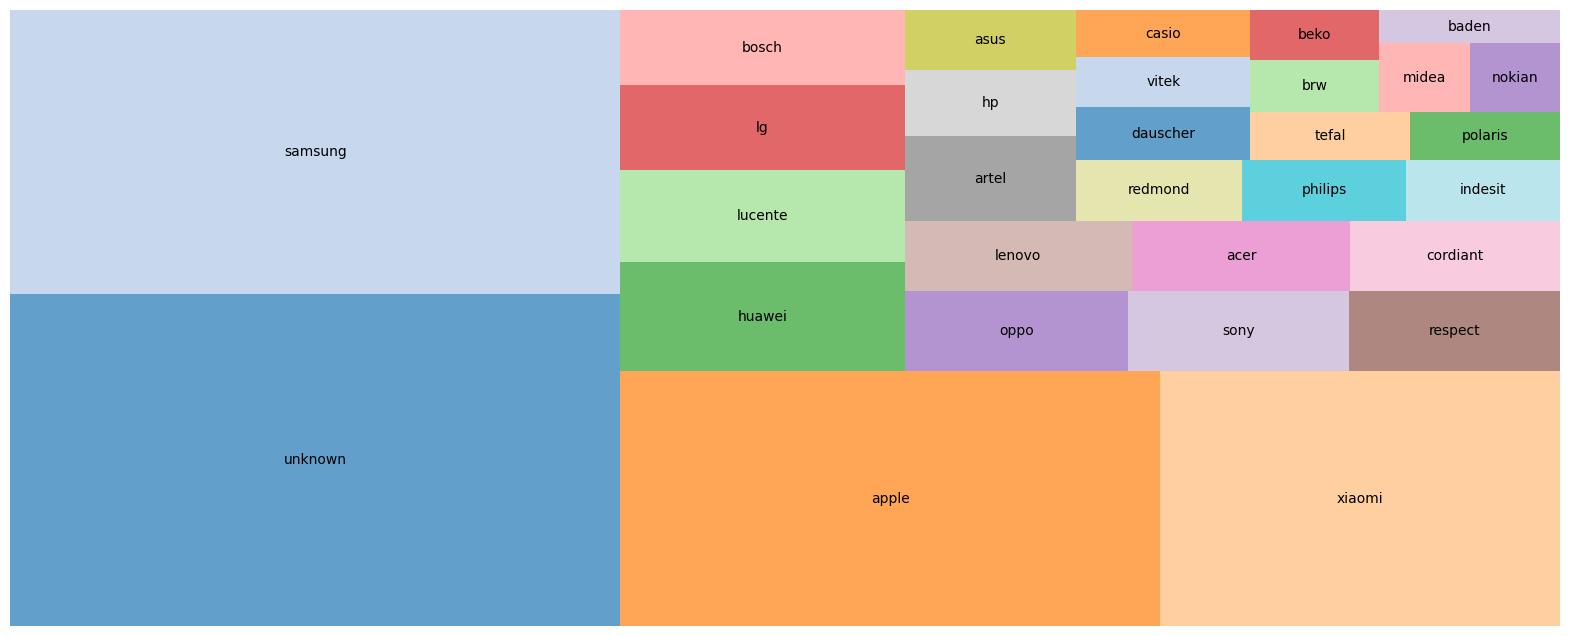

In [14]:

# Đếm top 30 thương hiệu
top_brand = (
    data.get_column("brand")
    .value_counts()
    .sort("count", descending=True)
    .head(30)
)
sizes = top_brand["count"].to_list()
labels = top_brand["brand"].to_list()
colors = plt.cm.tab20.colors

squarify.plot(
    sizes=sizes,
    label=labels,
    color=colors,
    alpha=0.7
)

plt.axis("off")
plt.show()

In [15]:
data["event_type"].value_counts()

event_type,count
str,u32
"""purchase""",916939
"""view""",63556110
"""cart""",3028920


In [16]:
purchase = (data.filter(pl.col("event_type") == "purchase").drop_nulls())

top_sellers = (
    data.group_by("brand")
    .agg(pl.len().alias("count"))
    .sort("count",descending=True)
    .head(20)
)
top_sellers     

brand,count
str,u32
"""unknown""",9218233
"""samsung""",7889244
"""apple""",6259377
"""xiaomi""",4638062
"""huawei""",1410126
…,…
"""hp""",515352
"""asus""",469241
"""redmond""",462034


## Predict at time of addition to shopping cart if user will purchase a given product?

### Prepare Data and Feature engineering

In [17]:
# Lọc khách hàng có cart hoặc purchase
cart_purchase_users = (
                        data.filter(pl.col("event_type").is_in(["cart","purchase"]))
                        .unique(subset = ["user_id"])
                        .drop_nulls()
)                   

In [18]:
# Đếm số activity trong session
activity_in_session = (
    data.filter(pl.col("user_id").is_in(cart_purchase_users.get_column("user_id")))
    .group_by("user_session")
    .agg(pl.len().alias("activity_count"))
)

/tmp/ipykernel_37585/135448334.py:3: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  data.filter(pl.col("user_id").is_in(cart_purchase_users.get_column("user_id")))


In [19]:
# Tạo nhãn is_purchased bằng Window Function (Cực đỉnh!)
df_targets = data.filter(pl.col("event_type").is_in(["cart", "purchase"])).unique(subset=["event_type", "product_id", "price", "user_id", "user_session"])

df_targets = df_targets.with_columns(
    # Nếu là purchase thì 1, ngược lại 0
    pl.when(pl.col("event_type") == "purchase").then(1).otherwise(0).alias("is_purchased")
).with_columns(
    # Lan truyền giá trị 1 cho tất cả các dòng có cùng user_session và product_id
    pl.col("is_purchased").max().over(["user_session", "product_id"])
)

In [20]:
# Tách Category bằng chuỗi (Split string)
df_targets = df_targets.filter(pl.col("event_type") == "cart").unique(subset=["user_session", "product_id", "is_purchased"]).drop_nulls()

df_targets = df_targets.with_columns([
    pl.col("event_date").dt.weekday().alias("event_weekday"),
    pl.col("category_code")
        .str.split(".")
        .list.get(0)
        .alias("category_code_level1"),
    pl.col("category_code")
        .str.split(".")
        .list.get(1, null_on_oob=True)
        .alias("category_code_level2")
])

In [21]:
# Merge activity_count
df_targets = df_targets.join(activity_in_session, on="user_session", how="left").with_columns(
    pl.col("activity_count").fill_null(0)
)

In [22]:
df_targets.head()

event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,event_date,is_purchased,event_weekday,category_code_level1,category_code_level2,activity_count
str,str,i64,i64,str,str,f32,i64,str,date,i32,i8,str,str,u32
"""2019-11-29 15:07:46 UTC""","""cart""",17300391,2053013553853497655,"""unknown""","""burberry""",52.290001,514640767,"""30ddd5fa-e72c-4a2d-9ddf-00e10b…",2019-11-29,0,5,"""unknown""",null,13
"""2019-11-10 18:08:56 UTC""","""cart""",1004749,2053013555631882655,"""electronics.smartphone""","""samsung""",194.759995,562317102,"""b561cf6a-4a0c-46b6-ad59-243129…",2019-11-10,0,7,"""electronics""","""smartphone""",15
"""2019-11-18 11:53:01 UTC""","""cart""",1005135,2053013555631882655,"""electronics.smartphone""","""apple""",1660.25,514156200,"""8cbb0f71-5636-428b-b74f-3826e1…",2019-11-18,1,1,"""electronics""","""smartphone""",3
"""2019-11-15 19:26:57 UTC""","""cart""",26400258,2053013563651392361,"""unknown""","""unknown""",156.5,564261404,"""a8d1d4ab-300a-489c-86db-4614f9…",2019-11-15,0,5,"""unknown""",null,16
"""2019-11-15 15:55:59 UTC""","""cart""",1004833,2053013555631882655,"""electronics.smartphone""","""samsung""",168.699997,516317240,"""25641cfd-fd7d-46be-a14e-207d7f…",2019-11-15,0,5,"""electronics""","""smartphone""",4


In [23]:
df_targets.schema

Schema([('event_time', String),
        ('event_type', String),
        ('product_id', Int64),
        ('category_id', Int64),
        ('category_code', String),
        ('brand', String),
        ('price', Float32),
        ('user_id', Int64),
        ('user_session', String),
        ('event_date', Date),
        ('is_purchased', Int32),
        ('event_weekday', Int8),
        ('category_code_level1', String),
        ('category_code_level2', String),
        ('activity_count', UInt32)])

#### Save new data structure for modeling

In [24]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from xgboost import plot_importance
from sklearn.utils import resample
from sklearn import metrics

In [71]:
is_purchase_set = df_targets.filter(pl.col("is_purchased") == 1)
is_purchase_set.shape

(713706, 15)

In [73]:
not_purchase_set = df_targets.filter(pl.col("is_purchased") == 0)
not_purchase_set.shape

(1340064, 15)

In [87]:
n_samples = 700000
is_purchase_set = resample(is_purchase_set,
                                replace = False, 
                                n_samples = n_samples,
                                random_state = 27)
not_purcahase_set = resample(not_purchase_set,
                                replace = False,
                                n_samples = n_samples,
                                random_state = 27)

In [88]:
features = df_targets.select(['brand', 'price', 'event_weekday', 'category_code_level1', 'category_code_level2', 'activity_count', 'is_purchased'])
features = features.with_columns([
    pl.col("brand").cast(pl.Categorical),
    pl.col("event_weekday").cast(pl.Categorical),
    pl.col("category_code_level1").cast(pl.Categorical),
    pl.col("category_code_level2").cast(pl.Categorical),
])
df_for_ml = features.to_pandas()
df_for_ml.head()

,brand,price,event_weekday,category_code_level1,category_code_level2,activity_count,is_purchased
0,burberry,52.290001,canyon,unknown,NaN,13,0
1,samsung,194.759995,domasnijocag,electronics,smartphone,15,0
2,apple,1660.250000,unknown,electronics,smartphone,3,1
3,unknown,156.500000,canyon,unknown,NaN,16,0
4,samsung,168.699997,canyon,electronics,smartphone,4,0


#### Encode categorical variables

In [89]:
X = df_for_ml.drop("is_purchased", axis=1)
y = df_for_ml["is_purchased"]

In [90]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=0
)

In [97]:
from xgboost import XGBClassifier
#---Model-1---
model = XGBClassifier(
    learning_rate=0.3,
    tree_method="hist",
    enable_categorical=True
)

# #---Model-2---
# model = XGBClassifier(
#     learning_rate=0.03,
#     tree_method="hist",
#     enable_categorical=True,
#     max_depth=5,          
#     min_child_weight=3,    
#     gamma=0.1              
# )

# #---Model-3---
# model = XGBClassifier(
#     learning_rate=0.3,
#     tree_method="hist",
#     enable_categorical=True,
#     subsample=0.8,         
#     colsample_bytree=0.8  
# )

# #---Model-4---
# model = XGBClassifier(
#     learning_rate=0.03,
#     tree_method="hist",
#     enable_categorical=True,
#     n_estimators=500       
# )
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [98]:
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))
print("Precision:",metrics.precision_score(y_test, y_pred))
print("Recall:",metrics.recall_score(y_test, y_pred))
print("fbeta:",metrics.fbeta_score(y_test, y_pred, average='weighted', beta=0.5))

Accuracy: 0.7030996654932149
Precision: 0.5948402547216024
Recall: 0.4589991810335776
fbeta: 0.6905374993004808
